# Finding 2026 NFL Draft Gems

**2026 Bitcamp Project**

Finding NFL Gems using combine data.  
Author: Aditya Eswaran

## Introduction

NFL teams are constantly searching for value outside the early rounds of the draft. Some players selected on Day 3 or late on Day 2 go on to become productive starters, while many others never carve out a major role. We assess whether the NFL Combine measurements can help identify those late-round success stories. To study that question, this notebook focuses on offensive skill positions and defines a draft gem as a player who was:
- drafted in Round 4 or later
- earned starter-level playing time
- produced strong fantasy results within their own position group

Historical gems are matched back to their combine measurements, and those patterns are then used to score the 2026 combine class for similar traits.

## Data Sources
This notebook uses three datasets:

`Historical combine data (2000–2025)`  
Used for player measurements and historical draft information.

`2026 combine data`  
Used to score current prospects for gem-like profiles.

`Yearly NFL offensive player stats`  
Used to measure post-draft outcomes such as offensive snaps and fantasy production.

In [2]:

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def resolve_file(filename: str) -> Path:
    candidates = [
        Path.cwd() / filename,
        Path("/content") / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in the notebook environment.")

combine_hist_path = resolve_file("combine-2000-2025.csv")
combine_2026_path = resolve_file("combine-data-2026.csv")
stats_path = resolve_file("yearly_player_stats_offense.csv")

print("Historical combine:", combine_hist_path)
print("2026 combine:", combine_2026_path)
print("Offensive stats:", stats_path)

Historical combine: c:\Users\adity\OneDrive\Documents\Bitcamp\combine-2000-2025.csv
2026 combine: c:\Users\adity\OneDrive\Documents\Bitcamp\combine-data-2026.csv
Offensive stats: c:\Users\adity\OneDrive\Documents\Bitcamp\yearly_player_stats_offense.csv


## Data Preprocessing & Curation

The goal of this section is to build a clean historical table that connects pre-draft combine traits to later NFL outcomes. The same cleaning logic is then applied to the 2026 combine class so that prospects can be scored using the same feature set. Because this notebook focuses on offensive draft gems, the final analytic dataset keeps only QB, RB, WR, and TE.

### 2.1 Load the Raw Data

In [3]:

combine_hist_raw = pd.read_csv(combine_hist_path)
combine_2026_raw = pd.read_csv(combine_2026_path)
stats_raw = pd.read_csv(stats_path)

print("Historical combine shape:", combine_hist_raw.shape)
print("2026 combine shape:", combine_2026_raw.shape)
print("Offensive stats shape:", stats_raw.shape)

Historical combine shape: (8649, 15)
2026 combine shape: (319, 14)
Offensive stats shape: (5192, 412)


In [4]:

print("Historical combine columns:")
print(combine_hist_raw.columns.tolist())

print("\n2026 combine columns:")
print(combine_2026_raw.columns.tolist())

print("\nOffensive stats columns (first 50):")
print(stats_raw.columns.tolist()[:50])

Historical combine columns:
['Player', 'Position', 'School', 'Height', 'Weight', '40-yd Dash', 'Vertical Jump', 'Bench Press', 'Broad Jump', '3-Cone Drill', '20-yd Shuttle', 'Team', 'Round', 'Pick', 'Year']

2026 combine columns:
['Player', 'Pos', 'School', 'College', 'Ht', 'Wt', '40yd', 'Vertical', 'Bench', 'Broad Jump', '3Cone', 'Shuttle', 'Drafted (tm/rnd/yr)', 'Player-additional']

Offensive stats columns (first 50):
['player_id', 'player_name', 'position', 'birth_year', 'draft_year', 'draft_round', 'draft_pick', 'draft_ovr', 'height', 'weight', 'college', 'season', 'team', 'conference', 'division', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'pass_attempts', 'complete_pass', 'incomplete_pass', 'passing_yards', 'receiving_yards', 'yards_after_catch', 'rush_attempts', 'rushing_yards', 'tackled_for_loss', 'first_down_pass', 'first_down_rush', 'third_down_converted', 'third_down_failed', 'fourth_down_converted', 'fourth_down_failed', 'rush_touchdown', 'pass_touchdown', 'safe

### 2.2 Clean the Historical and 2026 Combine Data

The combine files use slightly different column names, so both files are standardized into a shared schema. Only the measurements most relevant to athletic profile are kept for this project.

In [5]:

combine_hist = combine_hist_raw.rename(columns={
    "Player": "player",
    "Position": "position",
    "School": "school",
    "Height": "height",
    "Weight": "weight",
    "40-yd Dash": "forty",
    "Vertical Jump": "vertical",
    "Bench Press": "bench",
    "Broad Jump": "broad_jump",
    "3-Cone Drill": "three_cone",
    "20-yd Shuttle": "shuttle",
    "Team": "draft_team",
    "Round": "draft_round",
    "Pick": "draft_pick",
    "Year": "combine_year",
})

combine_2026 = combine_2026_raw.rename(columns={
    "Player": "player",
    "Pos": "position",
    "School": "school",
    "College": "college",
    "Ht": "height",
    "Wt": "weight",
    "40yd": "forty",
    "Vertical": "vertical",
    "Bench": "bench",
    "Broad Jump": "broad_jump",
    "3Cone": "three_cone",
    "Shuttle": "shuttle",
    "Drafted (tm/rnd/yr)": "drafted_info",
    "Player-additional": "player_additional",
})

combine_hist = combine_hist[[
    "player", "position", "school", "height", "weight", "forty", "vertical",
    "bench", "broad_jump", "three_cone", "shuttle", "draft_team",
    "draft_round", "draft_pick", "combine_year"
]].copy()

combine_2026 = combine_2026[[
    "player", "position", "school", "college", "height", "weight", "forty", "vertical",
    "bench", "broad_jump", "three_cone", "shuttle", "drafted_info"
]].copy()

for col in ["height", "weight", "forty", "vertical", "bench", "broad_jump", "three_cone", "shuttle"]:
    combine_hist[col] = pd.to_numeric(combine_hist[col], errors="coerce")
    combine_2026[col] = pd.to_numeric(combine_2026[col], errors="coerce")

combine_hist["draft_round"] = pd.to_numeric(combine_hist["draft_round"], errors="coerce")
combine_hist["draft_pick"] = pd.to_numeric(combine_hist["draft_pick"], errors="coerce")
combine_hist["combine_year"] = pd.to_numeric(combine_hist["combine_year"], errors="coerce")

off_positions = ["QB", "RB", "WR", "TE"]

combine_hist = combine_hist[combine_hist["position"].isin(off_positions)].copy()
combine_2026 = combine_2026[combine_2026["position"].isin(off_positions)].copy()

print("Historical offensive combine rows:", combine_hist.shape)
print("2026 offensive combine rows:", combine_2026.shape)

Historical offensive combine rows: (2905, 15)
2026 offensive combine rows: (109, 13)


### 2.3 Clean the NFL Performance Data

The offensive stats file contains one row per player-season. For this project, only the fields needed to define a gem are kept:

- `player identity`
- `position`
- `draft year and draft round`
- `fantasy points`
- `offensive snaps`

Fantasy production is evaluated within position, not across all players.

In [6]:

stats = stats_raw[[
    "player_name",
    "position",
    "draft_year",
    "draft_round",
    "draft_pick",
    "season",
    "fantasy_points_ppr",
    "offense_snaps",
]].copy()

stats = stats.rename(columns={"player_name": "player"})
stats = stats[stats["position"].isin(off_positions)].copy()

stats["draft_year"] = pd.to_numeric(stats["draft_year"], errors="coerce")
stats["draft_round"] = pd.to_numeric(stats["draft_round"], errors="coerce")
stats["draft_pick"] = pd.to_numeric(stats["draft_pick"], errors="coerce")
stats["season"] = pd.to_numeric(stats["season"], errors="coerce")
stats["fantasy_points_ppr"] = pd.to_numeric(stats["fantasy_points_ppr"], errors="coerce")
stats["offense_snaps"] = pd.to_numeric(stats["offense_snaps"], errors="coerce")

stats["starter_season"] = stats["offense_snaps"] >= 500
stats["pos_rank"] = stats.groupby(["season", "position"])["fantasy_points_ppr"] \
                         .rank(method="dense", ascending=False)

def strong_fantasy_threshold(row):
    if row["position"] in ["QB", "TE"]:
        return row["pos_rank"] <= 12
    if row["position"] in ["RB", "WR"]:
        return row["pos_rank"] <= 24
    return False

stats["strong_fantasy"] = stats.apply(strong_fantasy_threshold, axis=1)

# Keep the strongest season for each player based on playing time and fantasy output
stats_best = (
    stats.sort_values(
        by=["player", "starter_season", "strong_fantasy", "fantasy_points_ppr"],
        ascending=[True, False, False, False]
    )
    .drop_duplicates(subset=["player"], keep="first")
    .copy()
)

stats_best.head()

,player,position,draft_year,draft_round,draft_pick,season,fantasy_points_ppr,offense_snaps,starter_season,pos_rank,strong_fantasy
5158,A.J. Barner,TE,2024.0,4.0,21.0,2024,76.5,430.0,False,34.0,False
4129,A.J. Brown,WR,2019.0,2.0,19.0,2022,325.2,1183.0,True,13.0,True
2077,A.J. Derby,TE,2015.0,6.0,26.0,2017,50.4,285.0,False,39.0,False
4156,A.J. Dillon,RB,2020.0,2.0,30.0,2022,167.6,537.0,True,30.0,False
237,A.J. Green,WR,2011.0,1.0,4.0,2012,297.8,1008.0,True,16.0,True


### 2.4 Merge the Historical Combine Data with NFL Outcomes

Player names are normalized before merging to reduce mismatches caused by punctuation or suffixes.

In [7]:

def normalize_name(name: str) -> str:
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = re.sub(r"\b(jr|sr|ii|iii|iv|v)\b", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

combine_hist["player_key"] = combine_hist["player"].map(normalize_name)
stats_best["player_key"] = stats_best["player"].map(normalize_name)

historical = combine_hist.merge(
    stats_best[[
        "player_key", "position", "draft_year", "draft_round", "draft_pick",
        "season", "fantasy_points_ppr", "offense_snaps",
        "starter_season", "pos_rank", "strong_fantasy"
    ]],
    on="player_key",
    how="left",
    suffixes=("_combine", "_nfl")
)

historical["matched_to_stats"] = historical["season"].notna()
historical[["player", "position_combine", "combine_year", "season", "matched_to_stats"]].head()

,player,position_combine,combine_year,season,matched_to_stats
0,Xavier Worthy,WR,2024,2024.0,True
1,Donte' Stallworth,WR,2002,NaN,False
2,John Ross,WR,2017,2018.0,True
3,Chris Johnson,RB,2008,2013.0,True
4,Dri Archer,WR,2014,2014.0,True


In [8]:

match_summary = (
    historical.groupby("combine_year")["matched_to_stats"]
    .agg(["sum", "count", "mean"])
    .rename(columns={"sum": "matched_rows", "count": "total_rows", "mean": "match_rate"})
)

match_summary.tail(15)

,matched_rows,total_rows,match_rate
combine_year,,,
2011,55,113,0.486726
2012,52,105,0.495238
2013,54,106,0.509434
2014,62,121,0.512397
2015,59,107,0.551402
2016,54,100,0.540000
2017,65,122,0.532787
2018,66,111,0.594595
2019,60,113,0.530973


### 2.5 Build the Final Historical Training Window

The combine file goes back to 2000, but the available offensive stats mostly cover 2012–2024 NFL seasons. That means older draft classes are under-labeled because many players from the early 2000s were already out of the league before this performance window begins. To reduce that bias, the labeled training set is restricted to 2012–2020 combine classes. This gives each player multiple seasons to prove whether they became a gem by the end of 2024, while avoiding the almost-empty older classes and the still-too-recent 2021+ classes.

In [9]:
historical = historical.rename(columns={
    "position_combine": "position",
    "draft_round_combine": "combine_draft_round",
    "draft_pick_combine": "combine_draft_pick",
    "draft_round_nfl": "nfl_draft_round",
    "draft_pick_nfl": "nfl_draft_pick",
})

historical_labeled = historical[
    (historical["combine_year"].between(2012, 2020)) &
    (historical["matched_to_stats"])
].copy()

print("Full historical rows:", historical.shape)
print("Labeled training rows (2012-2020 with outcome match):", historical_labeled.shape)
historical_labeled[["player", "position", "combine_year", "season"]].head()

Full historical rows: (2905, 27)
Labeled training rows (2012-2020 with outcome match): (540, 27)


,player,position,combine_year,season
2,John Ross,WR,2017,2018.0
4,Dri Archer,WR,2014,2014.0
5,Marquise Goodwin,WR,2013,2017.0
6,Henry Ruggs III,WR,2020,2021.0
10,J.J. Nelson,WR,2015,2016.0


## Defining a Draft Gem

This project defines a draft gem using three conditions:

1. the player was drafted in Round 4 or later
2. the player recorded at least 500 offensive snaps
3. the player produced strong fantasy results within their own position group

This definition focuses on players who were not early premium picks, but still became meaningful offensive contributors.

### 3.1 Create the Gem Label

In [10]:

historical_labeled["late_round"] = historical_labeled["combine_draft_round"] >= 4

historical_labeled["gem"] = (
    historical_labeled["late_round"] &
    historical_labeled["starter_season"] &
    historical_labeled["strong_fantasy"]
)

historical_labeled[[
    "player", "position", "combine_year", "combine_draft_round",
    "offense_snaps", "fantasy_points_ppr", "pos_rank",
    "late_round", "starter_season", "strong_fantasy", "gem"
]].head(10)

,player,position,combine_year,combine_draft_round,offense_snaps,fantasy_points_ppr,pos_rank,late_round,starter_season,strong_fantasy,gem
2,John Ross,WR,2017,1.0,602.0,74.9,79.0,False,True,False,False
4,Dri Archer,WR,2014,3.0,153.0,36.7,66.0,False,False,False,False
5,Marquise Goodwin,WR,2013,3.0,769.0,164.6,34.0,False,True,False,False
6,Henry Ruggs III,WR,2020,1.0,668.0,169.0,40.0,False,True,False,False
10,J.J. Nelson,WR,2015,5.0,824.0,262.3,14.0,True,True,True,True
23,Travis Benjamin,WR,2012,4.0,1281.0,301.9,17.0,True,True,True,True
25,Curtis Samuel,WR,2017,2.0,659.0,210.1,34.0,False,True,False,False
26,Parris Campbell,WR,2019,2.0,980.0,137.1,52.0,False,True,False,False
27,Andy Isabella,WR,2019,2.0,491.0,83.3,81.0,False,False,False,False
34,Will Fuller,WR,2016,1.0,624.0,220.0,29.0,False,True,False,False


In [11]:

print("Gem counts:")
print(historical_labeled["gem"].value_counts(dropna=False))

print("\nGem counts by position:")
print(historical_labeled.groupby("position")["gem"].sum().sort_values(ascending=False))

Gem counts:
gem
False    498
True      42
Name: count, dtype: int64

Gem counts by position:
position
RB    20
WR    16
QB     3
TE     3
Name: gem, dtype: int64


### 3.2 Example Historical Gems

In [12]:

historical_examples = historical_labeled[historical_labeled["gem"]].sort_values(
    "fantasy_points_ppr", ascending=False
)[[
    "player", "position", "combine_year", "combine_draft_round",
    "fantasy_points_ppr", "offense_snaps", "pos_rank"
]]

historical_examples.head(15)

,player,position,combine_year,combine_draft_round,fantasy_points_ppr,offense_snaps,pos_rank
332,Tarik Cohen,RB,2017,4.0,548.12,1290.0,3.0
2249,Dak Prescott,QB,2016,4.0,443.46,1210.0,2.0
1457,Hunter Renfrow,WR,2019,5.0,422.40,1274.0,3.0
545,Stefon Diggs,WR,2015,5.0,387.70,1135.0,6.0
1637,Spencer Ware,RB,2013,6.0,379.70,1111.0,2.0
159,Nyheim Hines,RB,2018,4.0,377.30,803.0,2.0
1240,Jamison Crowder,WR,2015,4.0,375.40,1604.0,6.0
2379,Kirk Cousins,QB,2012,4.0,370.40,1171.0,7.0
1246,Aaron Jones,RB,2017,5.0,357.70,757.0,5.0
1371,Devonta Freeman,RB,2014,4.0,342.10,724.0,4.0


## Historical Gems Analysis

With the label in place, the next step is to examine how often gems appear and how they are distributed across draft rounds and positions.

### 4.1 How Many Gems Appear by Draft Class?

In [13]:

gem_by_year = historical_labeled.groupby("combine_year")["gem"].agg(["sum", "count"])
gem_by_year["gem_rate"] = gem_by_year["sum"] / gem_by_year["count"]
gem_by_year

,sum,count,gem_rate
combine_year,,,
2012,6,52,0.115385
2013,5,54,0.092593
2014,3,62,0.048387
2015,6,59,0.101695
2016,4,54,0.074074
2017,6,65,0.092308
2018,6,66,0.090909
2019,4,60,0.066667
2020,2,68,0.029412


### 4.2 How Many Gems Appear by Position?

In [14]:

gem_by_position = historical_labeled.groupby("position")["gem"].agg(["sum", "count"])
gem_by_position["gem_rate"] = gem_by_position["sum"] / gem_by_position["count"]
gem_by_position.sort_values("gem_rate", ascending=False)

,sum,count,gem_rate
position,,,
RB,20,148,0.135135
WR,16,224,0.071429
QB,3,76,0.039474
TE,3,92,0.032609


### 4.3 Compare Average Combine Traits for Gems vs Non-Gems

In [15]:

trait_cols = ["height", "weight", "forty", "vertical", "bench", "broad_jump", "three_cone", "shuttle"]

trait_summary = (
    historical_labeled.groupby("gem")[trait_cols]
    .mean()
    .T
    .rename(columns={False: "non_gem_avg", True: "gem_avg"})
)

trait_summary

gem,non_gem_avg,gem_avg
height,73.208835,71.285714
weight,218.353414,206.452381
forty,4.583873,4.522927
vertical,34.488399,34.907895
bench,17.334328,15.892857
broad_jump,119.834135,120.756757
three_cone,7.030728,6.987600
shuttle,4.271420,4.232000


## Exploratory Visualizations

These plots are used to inspect the shape of the historical gem population and to see whether certain combine traits stand out.

### 5.1 Gems by Draft Round

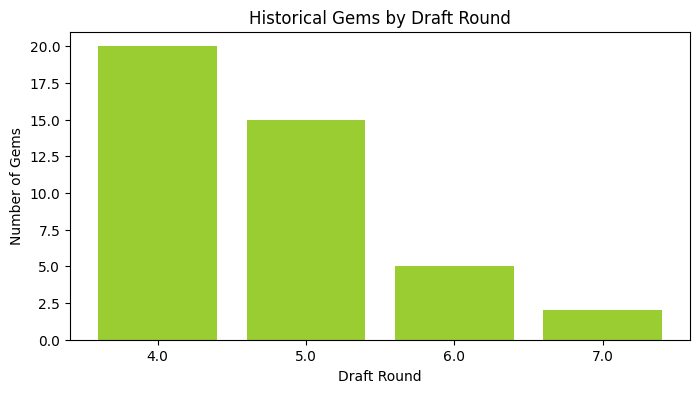

In [16]:

draft_round_counts = (
    historical_labeled[historical_labeled["gem"]]
    .groupby("combine_draft_round")
    .size()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(draft_round_counts.index.astype(str), draft_round_counts.values, color='yellowgreen')
plt.title("Historical Gems by Draft Round")
plt.xlabel("Draft Round")
plt.ylabel("Number of Gems")
plt.show()

### 5.2 Gems by Position

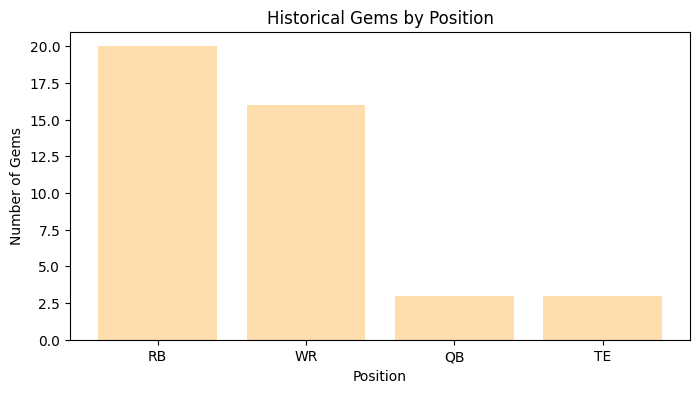

In [17]:

position_counts = (
    historical_labeled[historical_labeled["gem"]]
    .groupby("position")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))
plt.bar(position_counts.index, position_counts.values, color='navajowhite')
plt.title("Historical Gems by Position")
plt.xlabel("Position")
plt.ylabel("Number of Gems")
plt.show()

### 5.3 40-Yard Dash: Gems vs Non-Gems

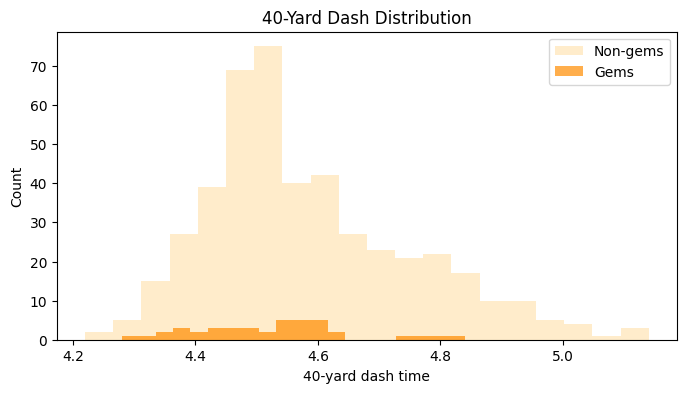

In [18]:

plt.figure(figsize=(8, 4))
plt.hist(historical_labeled.loc[historical_labeled["gem"] == False, "forty"].dropna(), bins=20, alpha=0.7, label="Non-gems", color='moccasin')
plt.hist(historical_labeled.loc[historical_labeled["gem"] == True, "forty"].dropna(), bins=20, alpha=0.7, label="Gems", color='darkorange')
plt.title("40-Yard Dash Distribution")
plt.xlabel("40-yard dash time")
plt.ylabel("Count")
plt.legend()
plt.show()

### 5.4 Vertical Jump: Gems vs Non-Gems

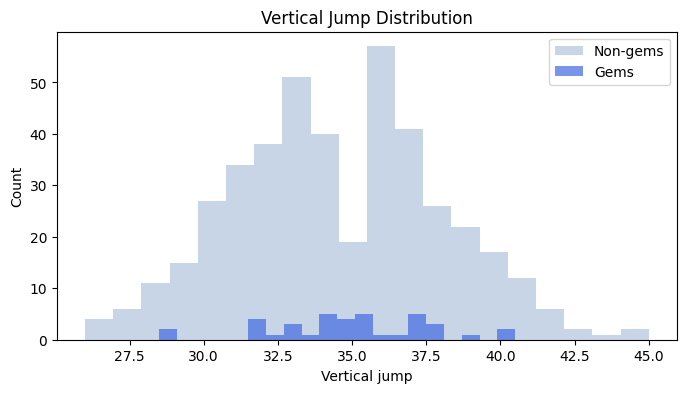

In [19]:

plt.figure(figsize=(8, 4))
plt.hist(historical_labeled.loc[historical_labeled["gem"] == False, "vertical"].dropna(), bins=20, alpha=0.7, label="Non-gems", color='lightsteelblue')
plt.hist(historical_labeled.loc[historical_labeled["gem"] == True, "vertical"].dropna(), bins=20, alpha=0.7, label="Gems", color='royalblue')
plt.title("Vertical Jump Distribution")
plt.xlabel("Vertical jump")
plt.ylabel("Count")
plt.legend()
plt.show()

### 5.5 Snap Count vs Fantasy Production

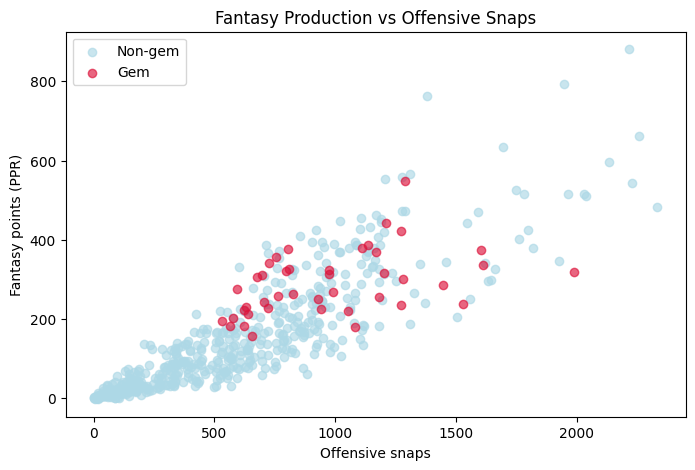

In [20]:
plot_df = historical_labeled.dropna(subset=["offense_snaps", "fantasy_points_ppr"]).copy()

plt.figure(figsize=(8, 5))
for label, subset in plot_df.groupby("gem"):
    plt.scatter(
        subset["offense_snaps"],
        subset["fantasy_points_ppr"],
        alpha=0.65,
        color="crimson" if label else "lightblue",
        label="Gem" if label else "Non-gem"
    )

plt.title("Fantasy Production vs Offensive Snaps")
plt.xlabel("Offensive snaps")
plt.ylabel("Fantasy points (PPR)")
plt.legend()
plt.show()

## Projecting 2026 Gem Candidates

The final step is to train a simple model on the labeled historical data and use it to score the 2026 combine class. This model does not use draft round as an input feature, because 2026 players have not been drafted yet. Instead, it learns a gem-like combine profile based on historical players who eventually became late-round gems.

### 6.1 Build the Modeling Table

In [21]:

feature_cols = ["position", "height", "weight", "forty", "vertical", "bench", "broad_jump", "three_cone", "shuttle"]
target_col = "gem"

model_df = historical_labeled[feature_cols + [target_col]].copy()
X = model_df[feature_cols]
y = model_df[target_col].astype(int)

print("Modeling rows:", X.shape[0])
print("Gem rate:", y.mean().round(4))

Modeling rows: 540
Gem rate: 0.0778


### 6.2 Train/Test Split and Model

A logistic regression model is used here because it is simple, interpretable, and appropriate for a small labeled dataset. The model uses standardized numeric combine traits and one-hot encoded position labels.

In [22]:

numeric_features = ["height", "weight", "forty", "vertical", "bench", "broad_jump", "three_cone", "shuttle"]
categorical_features = ["position"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

gem_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

gem_model.fit(X_train, y_train)
test_probs = gem_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, test_probs), 4))
print("Average precision:", round(average_precision_score(y_test, test_probs), 4))
print("\nClassification report:")
print(classification_report(y_test, test_preds, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_preds))

ROC-AUC: 0.6864
Average precision: 0.1321

Classification report:
              precision    recall  f1-score   support

           0      0.974     0.600     0.743       125
           1      0.138     0.800     0.235        10

    accuracy                          0.615       135
   macro avg      0.556     0.700     0.489       135
weighted avg      0.912     0.615     0.705       135

Confusion matrix:
[[75 50]
 [ 2  8]]


### 6.3 Inspect Model Coefficients

This step shows which features push the model toward a more gem-like score. Because the numeric features are standardized, the coefficient magnitudes are easier to compare.

In [23]:

# Refit on the full labeled set before interpretation and scoring 2026
gem_model.fit(X, y)

feature_names = gem_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = gem_model.named_steps["model"].coef_[0]

coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

coef_table

,feature,coefficient
0,cat__position_TE,0.496541
1,cat__position_RB,0.459091
2,num__vertical,0.036259
3,num__broad_jump,0.004295
4,num__three_cone,-0.041121
5,num__shuttle,-0.062529
6,cat__position_QB,-0.072585
7,num__height,-0.101478
8,num__forty,-0.173944
9,num__bench,-0.269969


### 6.4 Score the 2026 Combine Class

In [24]:

combine_2026_features = combine_2026[feature_cols].copy()
combine_2026["gem_like_score"] = gem_model.predict_proba(combine_2026_features)[:, 1]

top_2026 = combine_2026.sort_values("gem_like_score", ascending=False)[[
    "player", "position", "school", "height", "weight", "forty",
    "vertical", "bench", "broad_jump", "three_cone", "shuttle",
    "gem_like_score"
]].reset_index(drop=True)

top_2026.head(20)

,player,position,school,height,weight,forty,vertical,bench,broad_jump,three_cone,shuttle,gem_like_score
0,Desmond Reid,RB,Pittsburgh,NaN,174,NaN,NaN,NaN,NaN,NaN,NaN,0.844794
1,Demond Claiborne,RB,Wake Forest,NaN,188,4.37,NaN,NaN,122.0,NaN,NaN,0.813029
2,Eli Heidenreich,RB,Navy,NaN,198,4.44,35.5,16.0,120.0,NaN,NaN,0.764296
3,Robert Henry Jr.,RB,Texas-San Antonio,NaN,196,4.52,37.0,NaN,124.0,NaN,4.31,0.747522
4,Brenen Thompson,WR,Mississippi St.,NaN,164,4.26,NaN,NaN,NaN,NaN,NaN,0.710423
5,Emmett Johnson,RB,Nebraska,NaN,202,4.56,35.5,16.0,120.0,7.32,4.29,0.700372
6,Le'Veon Moss,RB,Texas A&M,NaN,203,NaN,NaN,NaN,NaN,NaN,NaN,0.698783
7,Jeremiyah Love,RB,Notre Dame,NaN,212,4.36,NaN,NaN,NaN,NaN,NaN,0.684289
8,J'Mari Taylor,RB,Virginia,NaN,199,NaN,34.5,20.0,115.0,NaN,NaN,0.680095
9,Jam Miller,RB,Alabama,NaN,209,4.42,30.5,NaN,115.0,NaN,NaN,0.678543


### 6.5 Top 2026 Candidates by Position

In [25]:

top_by_position = (
    combine_2026.sort_values(["position", "gem_like_score"], ascending=[True, False])
    .groupby("position")
    .head(5)
    [["player", "position", "school", "gem_like_score"]]
    .sort_values(["position", "gem_like_score"], ascending=[True, False])
    .reset_index(drop=True)
)

top_by_position

,player,position,school,gem_like_score
0,Garrett Nussmeier,QB,LSU,0.576845
1,Haynes King,QB,Georgia Tech,0.552114
2,Cade Klubnik,QB,Clemson,0.547904
3,Diego Pavia,QB,Vanderbilt,0.547904
4,Ty Simpson,QB,Alabama,0.518635
5,Desmond Reid,RB,Pittsburgh,0.844794
6,Demond Claiborne,RB,Wake Forest,0.813029
7,Eli Heidenreich,RB,Navy,0.764296
8,Robert Henry Jr.,RB,Texas-San Antonio,0.747522
9,Emmett Johnson,RB,Nebraska,0.700372


### 6.6 Important Interpretation Note

These 2026 scores do not mean the model is predicting exact NFL success. The scores only indicate which prospects have combine profiles that look more similar to the historical players who later became late-round gems. A player would only become a true draft gem under this research's definition if they are later selected in Round 4 or later and then go on to meet the snap-count and fantasy thresholds.

## Limitations

This research endeavor has several important limitations:

- The offensive stats data is strongest for the 2012–2024 NFL window, which is why the labeled historical training set is restricted to 2012–2020 combine classes
- Fantasy points are used as a measurable proxy for offensive success, but they do not capture every aspect of real football value
- Some combine drills are missing for many players, which means imputation is necessary in the model
- Name-based merging is imperfect and may miss some valid player matches
- The model is exploratory and should be interpreted as a ranking tool

## Conclusions

This project examined whether NFL Combine measurements can help identify late-round draft gems among offensive skill players. Using historical combine data, draft position, offensive snap counts, and fantasy production, I defined a draft gem as a player selected in Round 4 or later who earned at least 500 offensive snaps and produced strong fantasy results within their position. From there, I compared historical gems to non-gems and used those patterns to score the 2026 combine class. The results suggest that combine data does capture some useful signals of future late-round value, especially when players are evaluated within their own positions rather than across the entire draft pool. While combine measurements alone cannot explain a player’s full NFL outcome, they do help highlight prospects whose athletic profiles resemble past successful late-round contributors.

Among the 2026 class, the strongest gem-like candidates in this analysis included Garrett Nussmeier, Haynes King, and Cade Klubnik at quarterback; Desmond Reid, Demond Claiborne, and Eli Heidenreich at running back; Eli Stowers and RJ Maryland at tight end; and Brenen Thompson, Antonio Williams, and Eric Rivers at wide receiver. Running back showed the highest gem-like scores overall, with Desmond Reid standing out as the single strongest candidate in the 2026 group. Overall, this project shows that combine-based modeling can be a useful way to flag potential hidden value before or around the draft, especially for later-round prospects. At the same time, these predictions should be treated as indicators rather than guarantees, since real NFL success also depends on factors such as team fit, opportunity, injuries, and player development after entering the league.

## Citations

> Sipple, Isaak. NFL Combine 2000–2025. Kaggle, https://www.kaggle.com/datasets/isaaksipple/nfl-combine-2000-2025. Accessed 11 Apr. 2026.

> OpenAI. ChatGPT, GPT-5.4 Thinking, OpenAI, 11 Apr. 2026, chat.openai.com. Report cleanup

> Pro-Football-Reference. 2026 NFL Combine Results. Pro-Football-Reference.com, https://www.pro-football-reference.com/draft/2026-combine.htm. Accessed 11 Apr. 2026.